# Quadratic Programming

This tutorial introduces **Quadratic Programming (QP)** -- one of the most
important problem classes in mathematical optimization. QPs appear throughout
engineering, finance, statistics, and control theory.

By the end of this notebook you will be able to:

1. Define the standard form of a QP and explain why positive semi-definiteness
   of $Q$ guarantees convexity.
2. Formulate three practical QPs in `discopt`: portfolio optimization, ridge
   regression, and minimum-energy control.
3. Understand how `discopt` auto-detects QP structure and dispatches to a
   specialized interior-point solver.
4. Trace out the **efficient frontier** of a Markowitz portfolio.

**Prerequisites:** basic linear algebra (matrix-vector products, eigenvalues)
and familiarity with Python / NumPy. No prior optimization background is assumed.

**References:** {cite:p}`Boyd2004` is the standard graduate text on convex
optimization, and Chapter 4 covers QPs in detail.

In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_ENABLE_X64"] = "1"

import discopt.modeling as dm
import numpy as np

## 1. What Is a Quadratic Program?

A **quadratic program** (QP) is an optimization problem of the form

$$
\min_{x} \quad \tfrac{1}{2} x^\top Q\, x + c^\top x
\qquad \text{s.t.} \quad A\,x \le b, \quad x \ge 0,
$$

where

- $x \in \mathbb{R}^n$ is the vector of decision variables,
- $Q \in \mathbb{R}^{n \times n}$ is a symmetric matrix encoding the
  quadratic cost,
- $c \in \mathbb{R}^n$ is the linear cost vector,
- $A \in \mathbb{R}^{m \times n}$ and $b \in \mathbb{R}^m$ define the
  inequality constraints.

### Convexity and positive semi-definiteness

The objective $\tfrac{1}{2} x^\top Q\,x + c^\top x$ is **convex** if and
only if $Q$ is **positive semi-definite** (PSD), written $Q \succeq 0$.
Equivalently, all eigenvalues of $Q$ are non-negative. When $Q \succeq 0$,
any local minimum is a global minimum, and efficient polynomial-time
algorithms exist.

### QP detection in discopt

`discopt` automatically classifies your model by walking the expression DAG.
When it detects a quadratic objective with linear constraints and all
continuous variables, it dispatches to a specialized **QP interior-point
method** (IPM) {cite:p}`Mehrotra1992` that exploits the Schur complement
structure of the KKT system. This is dramatically faster than treating
the problem as a general NLP.

## 2. Example 1 -- Markowitz Portfolio Optimization

The **mean-variance portfolio** model {cite:p}`Markowitz1952` is perhaps
the most famous QP. Given $n$ assets with expected returns
$\mu \in \mathbb{R}^n$ and return covariance matrix
$\Sigma \in \mathbb{R}^{n \times n}$, we seek portfolio weights
$w \in \mathbb{R}^n$ that minimize risk (variance) for a target return:

$$
\min_{w} \quad w^\top \Sigma\, w
\qquad \text{s.t.} \quad
\mu^\top w \ge r_{\min}, \quad
\mathbf{1}^\top w = 1, \quad
w \ge 0.
$$

This is a convex QP because $\Sigma$ is positive semi-definite (it is a
covariance matrix).

In [2]:
n_assets = 5
np.random.seed(42)

# Expected returns (annualized)
mu = np.array([0.12, 0.10, 0.07, 0.03, 0.15])

# Build a positive-definite covariance matrix via Cholesky factor
L = np.array(
    [
        [0.1, 0, 0, 0, 0],
        [0.02, 0.08, 0, 0, 0],
        [0.01, 0.01, 0.06, 0, 0],
        [0.005, 0.005, 0.005, 0.04, 0],
        [0.03, 0.02, 0.01, 0.005, 0.12],
    ]
)
Sigma = L @ L.T

print("Expected returns:", mu)
print("\nCovariance matrix:")
print(np.array2string(Sigma, precision=5))
print("\nEigenvalues of Sigma:", np.linalg.eigvalsh(Sigma))
print("All eigenvalues >= 0:", np.all(np.linalg.eigvalsh(Sigma) >= -1e-12))

Expected returns: [0.12 0.1  0.07 0.03 0.15]

Covariance matrix:
[[0.01    0.002   0.001   0.0005  0.003  ]
 [0.002   0.0068  0.001   0.0005  0.0022 ]
 [0.001   0.001   0.0038  0.0004  0.0011 ]
 [0.0005  0.0005  0.0004  0.00168 0.0005 ]
 [0.003   0.0022  0.0011  0.0005  0.01582]]

Eigenvalues of Sigma: [0.00157401 0.00348735 0.00587773 0.00911997 0.01804094]
All eigenvalues >= 0: True


In [3]:
target_return = 0.10

m = dm.Model("markowitz")
w = m.continuous("w", shape=(n_assets,), lb=0, ub=1)

# Objective: minimize portfolio variance  w' Sigma w
m.minimize(
    dm.sum(
        lambda i: dm.sum(
            lambda j: Sigma[i, j] * w[i] * w[j],
            over=range(n_assets),
        ),
        over=range(n_assets),
    )
)

# Constraints: weights sum to 1, minimum return
m.subject_to(dm.sum(w) == 1, name="budget")
m.subject_to(
    dm.sum(lambda i: mu[i] * w[i], over=range(n_assets)) >= target_return,
    name="min_return",
)

result = m.solve()
print(f"Status:    {result.status}")
print(f"Variance:  {result.objective:.6f}")
print(f"Weights:   {np.round(result.value(w), 4)}")
print(f"Return:    {np.dot(mu, result.value(w)):.4f}  (target: {target_return})")

Status:    optimal
Variance:  0.002809
Weights:   [0.2085 0.2431 0.305  0.0599 0.1835]
Return:    0.1000  (target: 0.1)


In [4]:
from discopt._jax.problem_classifier import classify_problem

# Verify that discopt detects this as a QP
problem_class = classify_problem(m)
print(f"Problem class: {problem_class}")
print("discopt routes this to the specialized QP-IPM solver.")

Problem class: ProblemClass.QP
discopt routes this to the specialized QP-IPM solver.


### The efficient frontier

By sweeping the target return $r_{\min}$ from a low value to a high value
and solving the QP at each point, we trace out the **efficient frontier** --
the set of portfolios that achieve the lowest possible risk for each level
of expected return. No rational investor would choose a portfolio below
this curve, because a higher-return, same-risk alternative exists on it.

In [5]:
target_returns = np.linspace(0.04, 0.14, 10)
risks = []
achieved_returns = []

for r_target in target_returns:
    m = dm.Model("frontier")
    w = m.continuous("w", shape=(n_assets,), lb=0, ub=1)

    m.minimize(
        dm.sum(
            lambda i: dm.sum(
                lambda j: Sigma[i, j] * w[i] * w[j],
                over=range(n_assets),
            ),
            over=range(n_assets),
        )
    )
    m.subject_to(dm.sum(w) == 1, name="budget")
    m.subject_to(
        dm.sum(lambda i: mu[i] * w[i], over=range(n_assets)) >= r_target,
        name="min_return",
    )

    result = m.solve()
    if result.status in ("optimal", "feasible"):
        variance = result.objective
        risks.append(np.sqrt(max(variance, 0)))  # standard deviation
        achieved_returns.append(np.dot(mu, result.value(w)))
    else:
        print(f"  r_target={r_target:.2f}: {result.status}")

risks = np.array(risks)
achieved_returns = np.array(achieved_returns)
print(f"Computed {len(risks)} frontier points.")

Computed 10 frontier points.


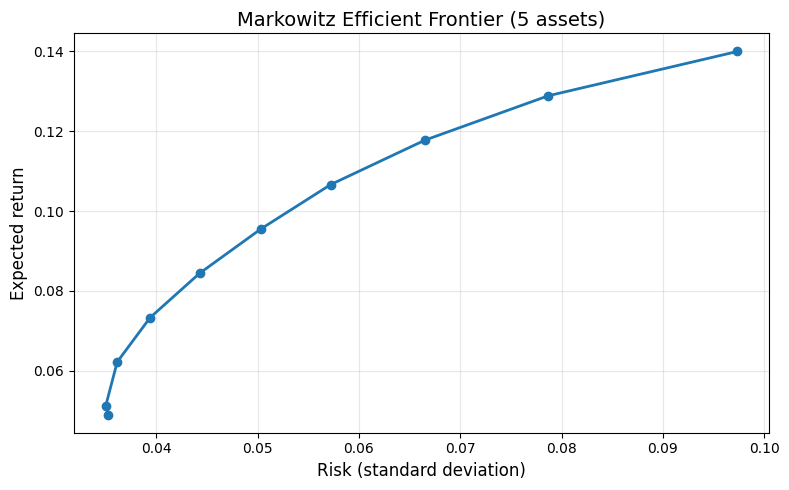

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(risks, achieved_returns, "o-", linewidth=2, markersize=6)
ax.set_xlabel("Risk (standard deviation)", fontsize=12)
ax.set_ylabel("Expected return", fontsize=12)
ax.set_title("Markowitz Efficient Frontier (5 assets)", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation.** The curve bows to the left -- as we demand higher
returns, risk increases, but *diversification* keeps the curve concave.
Points on the frontier dominate all portfolios to their right (same return,
lower risk). This fundamental insight earned Harry Markowitz the Nobel Prize
in Economics {cite:p}`Markowitz1952`.

## 3. Example 2 -- Ridge Regression as a QP

Fitting a linear model $\hat{y} = X\beta$ with $L_2$ regularization
(ridge regression) is secretly a QP {cite:p}`Boyd2004`:

$$
\min_{\beta} \quad \|y - X\beta\|_2^2 + \lambda \|\beta\|_2^2
= \beta^\top (X^\top X + \lambda I)\,\beta - 2\,y^\top X\,\beta + y^\top y.
$$

Since $X^\top X + \lambda I \succ 0$ for $\lambda > 0$, this QP is
strictly convex and has a unique solution. The closed-form solution is
$\beta^* = (X^\top X + \lambda I)^{-1} X^\top y$, which we will use
to verify the optimizer's answer.

In [7]:
np.random.seed(123)
n_samples, n_features = 50, 5

X = np.random.randn(n_samples, n_features)
true_beta = np.array([1.5, -2.0, 0.5, 0.0, 3.0])
y = X @ true_beta + 0.3 * np.random.randn(n_samples)

lam = 1.0  # regularization strength

print(f"Data: {n_samples} samples, {n_features} features")
print(f"True coefficients: {true_beta}")
print(f"Regularization lambda = {lam}")

Data: 50 samples, 5 features
True coefficients: [ 1.5 -2.   0.5  0.   3. ]
Regularization lambda = 1.0


In [8]:
m = dm.Model("ridge_regression")
beta = m.continuous("beta", shape=(n_features,), lb=-10, ub=10)

# Residual sum of squares: sum_i (y_i - sum_j X[i,j]*beta[j])^2
# + regularization: lambda * sum_j beta[j]^2
m.minimize(
    dm.sum(
        lambda i: (y[i] - dm.sum(lambda j: X[i, j] * beta[j], over=range(n_features))) ** 2,
        over=range(n_samples),
    )
    + lam * dm.sum(lambda j: beta[j] ** 2, over=range(n_features))
)

result = m.solve()
print(f"Status: {result.status}")
print(f"Objective (RSS + penalty): {result.objective:.4f}")

Status: optimal
Objective (RSS + penalty): 19.7872


In [9]:
# Closed-form ridge solution for verification
beta_cf = np.linalg.solve(X.T @ X + lam * np.eye(n_features), X.T @ y)
beta_opt = result.value(beta)

print(f"{'Coefficient':<14s} {'True':>8s} {'discopt':>10s} {'Closed-form':>12s}")
print("-" * 48)
for j in range(n_features):
    print(f"  beta[{j}]       {true_beta[j]:8.4f} {beta_opt[j]:10.4f} {beta_cf[j]:12.4f}")

max_error = np.max(np.abs(beta_opt - beta_cf))
print(f"\nMax |discopt - closed-form|: {max_error:.2e}")

Coefficient        True    discopt  Closed-form
------------------------------------------------
  beta[0]         1.5000     1.4290       1.4290
  beta[1]        -2.0000    -1.9478      -1.9478
  beta[2]         0.5000     0.4239       0.4239
  beta[3]         0.0000    -0.0034      -0.0034
  beta[4]         3.0000     2.9414       2.9414

Max |discopt - closed-form|: 5.10e-09


## 4. Example 3 -- Minimum-Energy Control

In discrete-time **linear-quadratic regulator** (LQR) problems we want to
drive a system from an initial state $x_0$ to the origin using minimum
control energy. Consider the scalar system

$$
x_{t+1} = a\, x_t + b\, u_t, \qquad t = 0, 1, \ldots, T-1,
$$

with the objective

$$
\min_{u_0, \ldots, u_{T-1}} \quad \sum_{t=0}^{T-1} u_t^2.
$$

This is a QP in the controls $u_t$ (and the auxiliary state variables
$x_t$), with the dynamics as equality constraints {cite:p}`Boyd2004`.

In [10]:
# System parameters
a, b = 1.1, 1.0  # slightly unstable open-loop system
T = 10  # horizon
x0 = 5.0  # initial state

m = dm.Model("lqr")
x = m.continuous("x", shape=(T + 1,), lb=-50, ub=50)  # states x[0]..x[T]
u = m.continuous("u", shape=(T,), lb=-10, ub=10)  # controls u[0]..u[T-1]

# Objective: minimize sum of squared controls
m.minimize(dm.sum(lambda t: u[t] ** 2, over=range(T)))

# Initial condition
m.subject_to(x[0] == x0, name="initial")

# Dynamics constraints: x[t+1] = a*x[t] + b*u[t]
for t in range(T):
    m.subject_to(x[t + 1] == a * x[t] + b * u[t], name=f"dynamics_{t}")

# Terminal constraint: drive state to zero
m.subject_to(x[T] == 0, name="terminal")

result = m.solve()
print(f"Status:    {result.status}")
print(f"Total energy (sum u^2): {result.objective:.4f}")
print(f"\nState trajectory:  {np.round(result.value(x), 3)}")
print(f"Control trajectory: {np.round(result.value(u), 3)}")

Status:    optimal
Total energy (sum u^2): 6.1666

State trajectory:  [5.    4.379 3.797 3.251 2.733 2.241 1.769 1.313 0.868 0.432 0.   ]
Control trajectory: [-1.121 -1.019 -0.927 -0.842 -0.766 -0.696 -0.633 -0.575 -0.523 -0.476]


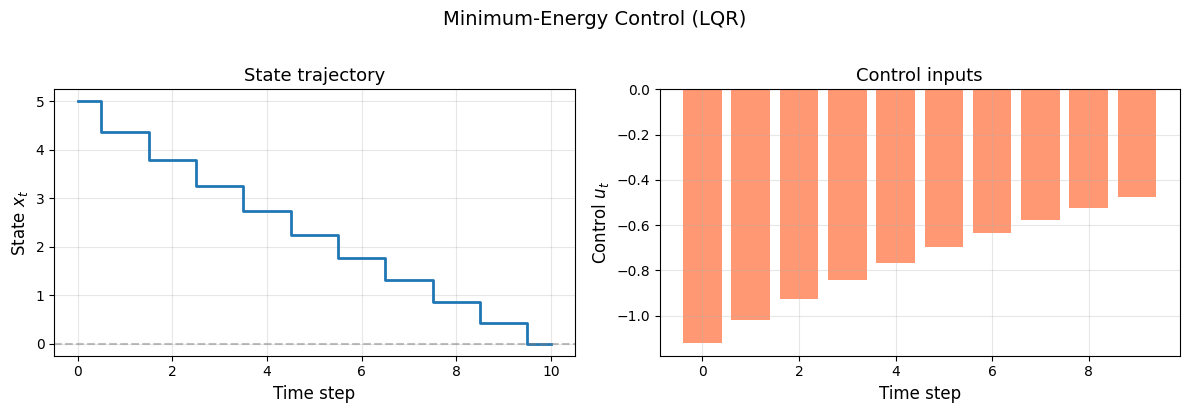

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

times_x = np.arange(T + 1)
times_u = np.arange(T)

ax1.step(times_x, result.value(x), where="mid", linewidth=2)
ax1.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax1.set_xlabel("Time step", fontsize=12)
ax1.set_ylabel("State $x_t$", fontsize=12)
ax1.set_title("State trajectory", fontsize=13)
ax1.grid(True, alpha=0.3)

ax2.bar(times_u, result.value(u), color="coral", alpha=0.8)
ax2.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax2.set_xlabel("Time step", fontsize=12)
ax2.set_ylabel("Control $u_t$", fontsize=12)
ax2.set_title("Control inputs", fontsize=13)
ax2.grid(True, alpha=0.3)

plt.suptitle("Minimum-Energy Control (LQR)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. How discopt Solves QPs

When `discopt` detects a QP, it follows a specialized path:

1. **Algebraic coefficient extraction.** Instead of using automatic
   differentiation (which would require $O(n^2)$ Hessian evaluations),
   `discopt` walks the expression DAG to directly extract the $Q$ matrix,
   linear cost vector $c$, and constraint matrix $A$. This is
   100--200x faster than the autodiff path.

2. **Carry-based IPM.** The extracted data is fed into a
   Mehrotra predictor-corrector interior-point method {cite:p}`Mehrotra1992`
   that stores all problem data in the `while_loop` carry state
   (rather than in closures), enabling JIT cache reuse across
   different problem instances of the same size.

3. **Schur complement.** The KKT system
   $\begin{bmatrix} Q + \delta_p I & A^\top \\ A & -\delta_d I \end{bmatrix}$
   is reduced via the Schur complement and solved with a Cholesky
   factorization, exploiting the block structure for efficiency.

**Bulk API.** For large-scale QPs where building the objective
expression-by-expression would be slow, `discopt` provides
`add_quadratic_objective(Q, c, x)` which accepts the $Q$ matrix and
$c$ vector directly, bypassing DAG construction entirely.

For active-set methods as an alternative to IPM, see {cite:p}`Goldfarb1983`.
For a comprehensive treatment of numerical optimization algorithms,
see {cite:p}`Nocedal2006`.

In [12]:
from discopt._jax.problem_classifier import classify_problem, extract_qp_data_algebraic

# Rebuild a small portfolio QP to inspect extracted data
m = dm.Model("qp_inspect")
w = m.continuous("w", shape=(3,), lb=0, ub=1)
Sigma3 = Sigma[:3, :3]

m.minimize(
    dm.sum(
        lambda i: dm.sum(
            lambda j: Sigma3[i, j] * w[i] * w[j],
            over=range(3),
        ),
        over=range(3),
    )
)
m.subject_to(dm.sum(w) == 1, name="budget")

pc = classify_problem(m)
print(f"Detected class: {pc}")

qp_data = extract_qp_data_algebraic(m)
print("\nQ matrix (Hessian of objective):")
print(np.array2string(np.array(qp_data.Q), precision=5))
print(f"\nc vector (linear cost): {np.array(qp_data.c)}")

Detected class: ProblemClass.QP

Q matrix (Hessian of objective):
[[0.02   0.004  0.002 ]
 [0.004  0.0136 0.002 ]
 [0.002  0.002  0.0076]]

c vector (linear cost): [0. 0. 0.]


## 6. Non-convex QPs: A Warning

When $Q$ has negative eigenvalues (i.e., $Q$ is **not** PSD), the QP is
non-convex. The objective has saddle points and potentially multiple local
minima. A local solver may return a local (not global) optimum.

Below we maximize a quadratic using `m.maximize()`, which internally
corresponds to a negative-definite $Q$.

In [13]:
m = dm.Model("non_convex_qp")
x = m.continuous("x", lb=-5, ub=5)
y = m.continuous("y", lb=-5, ub=5)

# Maximizing x^2 + y^2: non-convex!
m.maximize(x**2 + y**2)
m.subject_to(x + y <= 6)

result = m.solve()
print(f"Status:    {result.status}")
print(f"Objective: {result.objective:.4f}")
print(f"x = {result.value(x):.4f}")
print(f"y = {result.value(y):.4f}")
print()
print("Note: The global maximum of x^2 + y^2 on [-5,5]^2 is 50")
print("at a corner (5, -5) or (-5, 5), etc.")
print("A local solver may find a different local optimum.")

Status:    optimal
Objective: 18.0000
x = 3.0000
y = 3.0000

Note: The global maximum of x^2 + y^2 on [-5,5]^2 is 50
at a corner (5, -5) or (-5, 5), etc.
A local solver may find a different local optimum.


## 7. Exercise: SVM Dual as a QP

The dual of a **support vector machine** (SVM) for binary classification
is a classic QP. Given $m$ training points $(x_i, y_i)$ with
$y_i \in \{-1, +1\}$, the dual SVM is:

$$
\max_{\alpha} \quad \sum_{i=1}^{m} \alpha_i
  - \tfrac{1}{2} \sum_{i,j} \alpha_i \alpha_j\, y_i y_j\, x_i^\top x_j
\qquad \text{s.t.} \quad
\sum_i \alpha_i y_i = 0, \quad
0 \le \alpha_i \le C.
$$

This is a concave maximization (equivalently, convex minimization by
negation) because the kernel matrix $K_{ij} = y_i y_j x_i^\top x_j$
is positive semi-definite.

**Task:** Complete the code below to solve the dual SVM on a toy 2D
dataset.

In [14]:
# Generate a simple linearly separable 2D dataset
np.random.seed(7)
n_pos = 15
n_neg = 15
n_total = n_pos + n_neg

X_pos = np.random.randn(n_pos, 2) + np.array([2.0, 2.0])
X_neg = np.random.randn(n_neg, 2) + np.array([-2.0, -2.0])
X_data = np.vstack([X_pos, X_neg])
y_labels = np.concatenate([np.ones(n_pos), -np.ones(n_neg)])

C = 10.0  # regularization parameter

# Kernel matrix
K = np.zeros((n_total, n_total))
for i in range(n_total):
    for j in range(n_total):
        K[i, j] = y_labels[i] * y_labels[j] * np.dot(X_data[i], X_data[j])

# --- YOUR CODE HERE ---
# 1. Create a Model
# 2. Add alpha variables with lb=0, ub=C
# 3. Maximize: sum(alpha) - 0.5 * sum_ij alpha_i * alpha_j * K[i,j]
#    (Hint: use m.maximize(...))
# 4. Add constraint: sum_i alpha_i * y_labels[i] == 0
# 5. Solve and print results
# --- END YOUR CODE ---

In [15]:
# --- SOLUTION ---
m = dm.Model("svm_dual")
alpha = m.continuous("alpha", shape=(n_total,), lb=0, ub=C)

# Maximize the dual SVM objective
m.maximize(
    dm.sum(alpha)
    - 0.5
    * dm.sum(
        lambda i: dm.sum(
            lambda j: K[i, j] * alpha[i] * alpha[j],
            over=range(n_total),
        ),
        over=range(n_total),
    )
)

# Equality constraint: sum of alpha_i * y_i = 0
m.subject_to(dm.sum(lambda i: y_labels[i] * alpha[i], over=range(n_total)) == 0, name="balance")

result = m.solve()
print(f"Status: {result.status}")
print(f"Objective: {result.objective:.4f}")

alpha_vals = result.value(alpha)
# Support vectors have alpha > small threshold
sv_mask = alpha_vals > 1e-4
print(f"Number of support vectors: {np.sum(sv_mask)} / {n_total}")
print(f"Support vector indices: {np.where(sv_mask)[0]}")

Status: optimal
Objective: 0.4015
Number of support vectors: 3 / 30
Support vector indices: [13 23 25]


## 8. Summary

In this tutorial we covered:

| Topic | Key takeaway |
|-------|-------------|
| QP standard form | $\min \tfrac{1}{2} x^\top Q x + c^\top x$ s.t. $Ax \le b$ |
| Convexity | $Q \succeq 0$ (PSD) guarantees a unique global minimum |
| Portfolio optimization | Markowitz mean-variance is a QP; efficient frontier from parametric solves {cite:p}`Markowitz1952` |
| Ridge regression | $L_2$-regularized least squares is a QP with $Q = X^\top X + \lambda I$ |
| Minimum-energy control | LQR with linear dynamics yields a QP in controls |
| Algebraic extraction | `discopt` walks the DAG to extract $Q, c, A, b$ (100--200x faster than autodiff) |
| Non-convex QPs | Indefinite $Q$ leads to non-convex problems; local solvers may miss the global optimum |

### Next steps

- **Mixed-integer QP (MIQP):** Add binary variables to the portfolio model
  (e.g., cardinality constraints) -- see `tutorial_miqp`.
- **Mixed-integer LP (MILP):** When the objective is linear -- see
  `tutorial_milp`.
- **Nonlinear programming (NLP):** For general smooth objectives -- see
  `tutorial_minlp`.